In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)



In [37]:
df = pd.read_csv("dataset_particulas_unificado_F.csv")
df.head()


,pt,eta,phi,particle_type,event_id
0,2.06272,-0.233066,-0.154099,electron,Event_1203594102
1,2.65992,2.005970,-2.187040,electron,Event_1203594102
2,27.85330,-1.332450,1.910920,tau,Event_1203594102
3,1.58189,-1.451010,-0.961732,tau,Event_1203594102
4,2.12971,-1.054230,-2.037100,tau,Event_1203594102


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10769 entries, 0 to 10768
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pt             10769 non-null  float64
 1   eta            10769 non-null  float64
 2   phi            10769 non-null  float64
 3   particle_type  10769 non-null  object 
 4   event_id       10769 non-null  object 
dtypes: float64(3), object(2)
memory usage: 420.8+ KB


In [41]:
# Features
X = df[['pt', 'eta', 'phi', 'event_id']]

# Target
y = df['particle_type']

# Entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [42]:
# Escalador
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo
logreg = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs'
)

# Entrenamiento ÚNICO
logreg.fit(X_train_scaled, y_train)


ValueError: could not convert string to float: 'Event_651992907'

In [30]:
# ============================================
# 5. ESCALADO NUMÉRICO
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Escalado completado.")


Escalado completado.


In [31]:
%%time
# ============================================
# 6. ENTRENAR LOGISTIC REGRESSION (solo una vez)
# ============================================

model = LogisticRegression(
    max_iter=2000,
    multi_class='auto',
    solver='lbfgs'
)

model.fit(X_train_scaled, y_train)

print("Entrenamiento completado.")


Entrenamiento completado.
CPU times: user 115 ms, sys: 705 µs, total: 116 ms
Wall time: 117 ms


In [32]:
# ============================================
# 7. REPORTE DE CLASIFICACIÓN
# ============================================

y_pred = model.predict(X_test_scaled)

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))



===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

    electron       0.00      0.00      0.00        13
        muon       0.00      0.00      0.00        32
      photon       0.22      0.07      0.11        28
         tau       0.71      0.32      0.44       942
       track       0.71      0.95      0.81      1678

    accuracy                           0.71      2693
   macro avg       0.33      0.27      0.27      2693
weighted avg       0.69      0.71      0.66      2693



/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


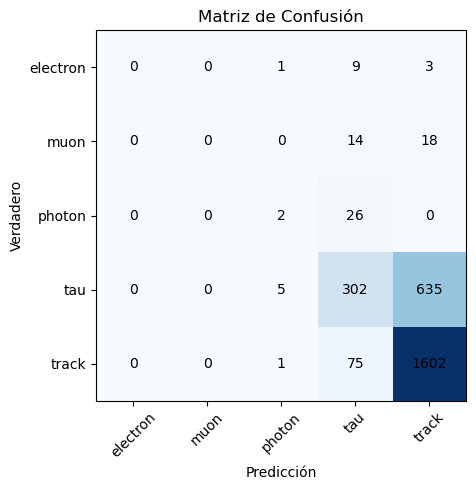

In [33]:
# ============================================
# 8. MATRIZ DE CONFUSIÓN
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")

plt.xticks(np.arange(len(encoder.classes_)), encoder.classes_, rotation=45)
plt.yticks(np.arange(len(encoder.classes_)), encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()


/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


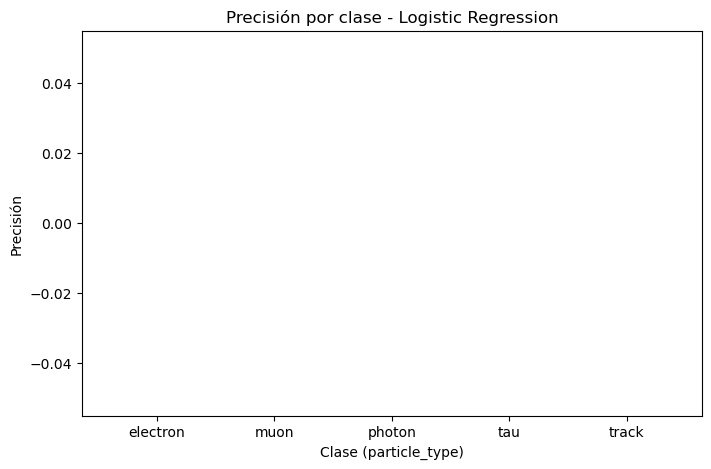

In [36]:
from sklearn.metrics import precision_score

# Obtener precisiones por clase
labels = sorted(y.unique())
precisiones = precision_score(y_test, y_pred, average=None, labels=labels)

# Graficar
plt.figure(figsize=(8,5))
plt.bar(labels, precisiones)
plt.xlabel("Clase (particle_type)")
plt.ylabel("Precisión")
plt.title("Precisión por clase - Logistic Regression")
plt.show()


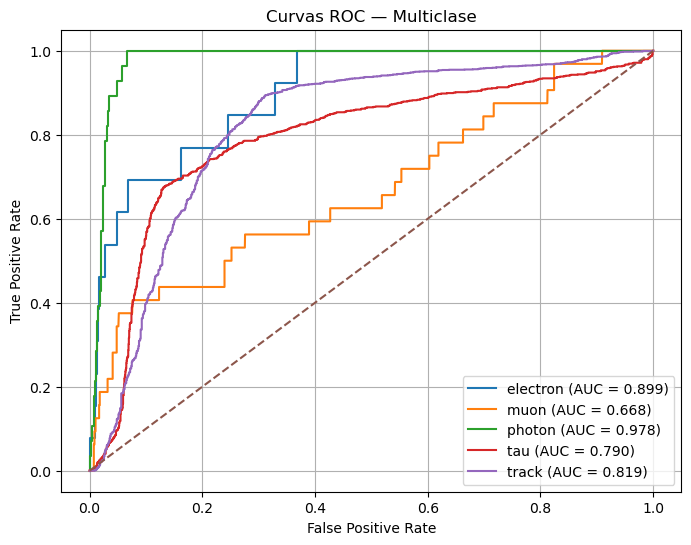

In [34]:
# ============================================
# 9. CURVAS ROC MULTICLASE
# ============================================

y_proba = model.predict_proba(X_test_scaled)
n_classes = len(encoder.classes_)

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{encoder.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — Multiclase")
plt.legend()
plt.grid()
plt.show()


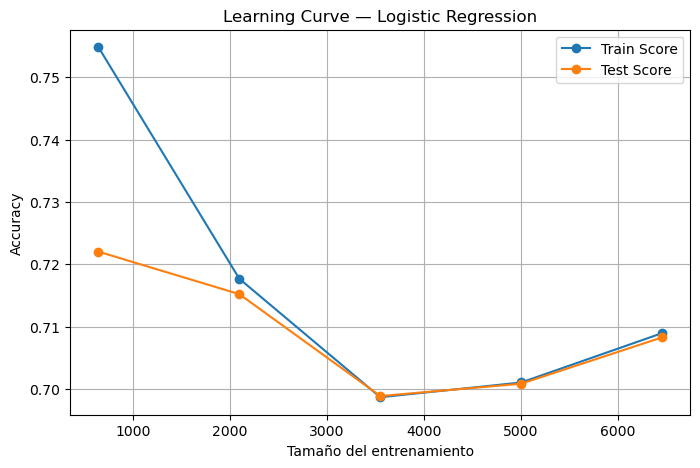

In [35]:
# ============================================
# 10. CURVA DE APRENDIZAJE
# ============================================

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Train Score')
plt.plot(train_sizes, test_mean,  marker='o', label='Test Score')

plt.xlabel("Tamaño del entrenamiento")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Logistic Regression")
plt.legend()
plt.grid()
plt.show()
